Feature importance answers the question:

**"What actually drives electricity prices in your model?"** 

We'll use two methods — XGBoost's built-in importance first, then SHAP which is significantly more powerful.

In [1]:
import os
os.chdir(r'C:\Projects\lmp-forecaster')

import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load data and trained model
# v2 = 4-year (2021-2024) feature matrix; xgb_lmp_v1.json is the model trained
# in notebook 03 on 2022-2023. SHAP is computed on the 2024 holdout below.
df = pd.read_csv(
    'data/features/feature_matrix_v2.csv',
    parse_dates=['Time'],
    index_col='Time'
)

TARGET   = 'LMP'
FEATURES = [col for col in df.columns if col not in [
    'LMP', 'Energy', 'Congestion', 'Loss'
]]

X = df[FEATURES]
y = df[TARGET]

# Load saved model
model = xgb.XGBRegressor()
model.load_model('models/xgb_lmp_v1.json')

# Use test set for SHAP analysis
X_test = X[X.index >= '2024-01-01']
y_test = y[y.index >= '2024-01-01']

print(f"Features: {len(FEATURES)}")
print(f"Test rows: {len(X_test):,}")
print("Model loaded successfully")

Features: 33
Test rows: 8,784
Model loaded successfully


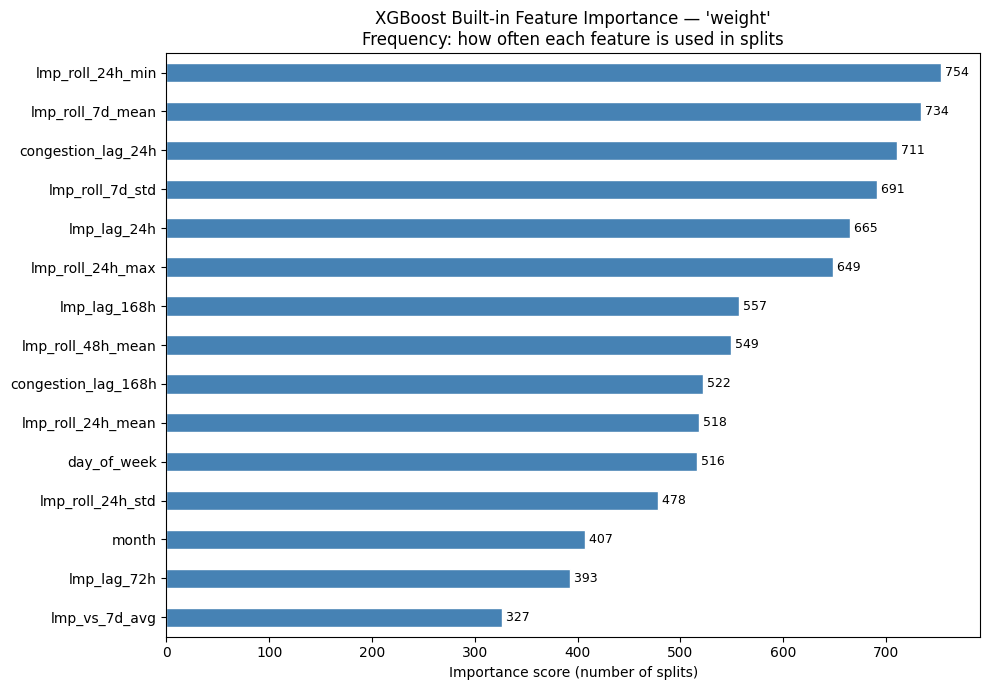

In [2]:
# --- Built-in XGBoost Importance: 'weight' (split frequency) ---
# weight = how often each feature is used as a split point across all the trees.
imp = (pd.Series(model.get_booster().get_score(importance_type='weight'))
         .sort_values(ascending=True).tail(15))      # top 15

fig, ax = plt.subplots(figsize=(10, 7))
imp.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title("XGBoost Built-in Feature Importance — 'weight'\n"
             "Frequency: how often each feature is used in splits", fontsize=12)
ax.set_xlabel('Importance score (number of splits)')
for i, v in enumerate(imp.values):
    ax.text(v, i, f' {int(v)}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('results/xgb_builtin_importance.png', dpi=150)
plt.show()

### Chart 1 — Built-in Importance (`weight`)
`weight` counts how often each feature is used as a split across all the trees. Here
`lmp_roll_24h_min` and the other rolling / lag features rise to the top — they're convenient,
frequently-used split points.

**Caveat — frequency ≠ importance.** A feature can be split on very often yet move the prediction
only a little (it's just a handy place to cut the data). XGBoost also offers `gain` (accuracy
improvement per split) and `cover` (samples affected), and the three measures often **disagree** —
e.g. `gain` is led by `lmp_lag_24h`/`spike_lag_24h`, not `lmp_roll_24h_min`. That ambiguity is
exactly why we turn to **SHAP** next: it gives one consistent, magnitude-*and*-direction answer.

Built-in importance has a flaw — it doesn't tell you direction or magnitude. SHAP fixes both.

In [3]:
# --- SHAP Values ---
# We compute exact TreeSHAP values on the test set.
#
# NOTE: shap 0.45.1's shap.TreeExplainer(model) can't parse XGBoost 3.x's
# serialized base_score (stored as a string like '[4.6E1]'), so we call
# XGBoost's built-in TreeSHAP via pred_contribs instead. It's the *same*
# Lundberg TreeSHAP algorithm shap.TreeExplainer would run, just invoked
# natively — and shap is still used below for the plots.

# Use a sample of 2000 rows for speed — still statistically representative.
# Seed the sample so the ranking below is reproducible across runs.
np.random.seed(42)
sample_idx  = np.random.choice(len(X_test), size=2000, replace=False)
X_sample    = X_test.iloc[sample_idx]

print("Calculating SHAP values... (takes ~30 seconds)")
booster      = model.get_booster()
_contribs    = booster.predict(xgb.DMatrix(X_sample), pred_contribs=True)
shap_values  = _contribs[:, :-1]   # drop the final column (bias / base value)
print(f"SHAP values shape: {shap_values.shape}")
print("Done.")

Calculating SHAP values... (takes ~30 seconds)


SHAP values shape: (2000, 33)
Done.


## SHAP Feature Importance

The canonical SHAP global feature-importance plot: each feature's **mean absolute SHAP value**
across all sampled hours (built with SHAP's own `summary_plot(..., plot_type="bar")`). Higher =
the feature moves the LMP prediction more, on average.

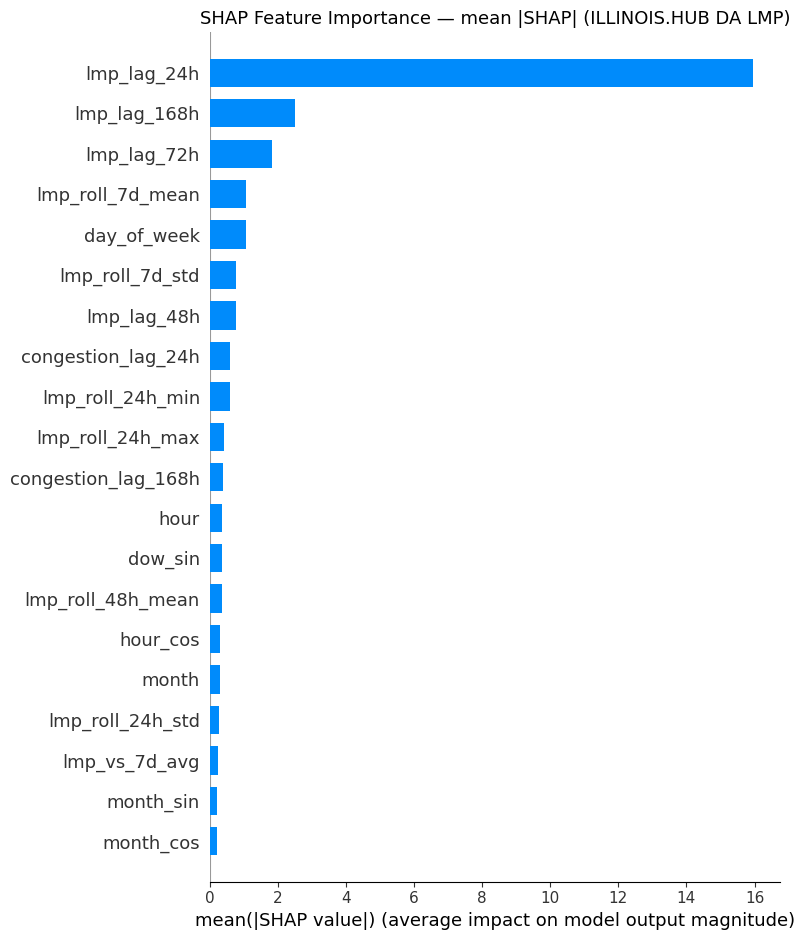

In [4]:
# --- SHAP Feature Importance (global) — SHAP's native bar of mean |SHAP| ---
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=FEATURES,
    plot_type='bar',
    max_display=20,
    show=False
)
plt.title('SHAP Feature Importance — mean |SHAP| (ILLINOIS.HUB DA LMP)', fontsize=13)
plt.tight_layout()
plt.savefig('results/shap_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

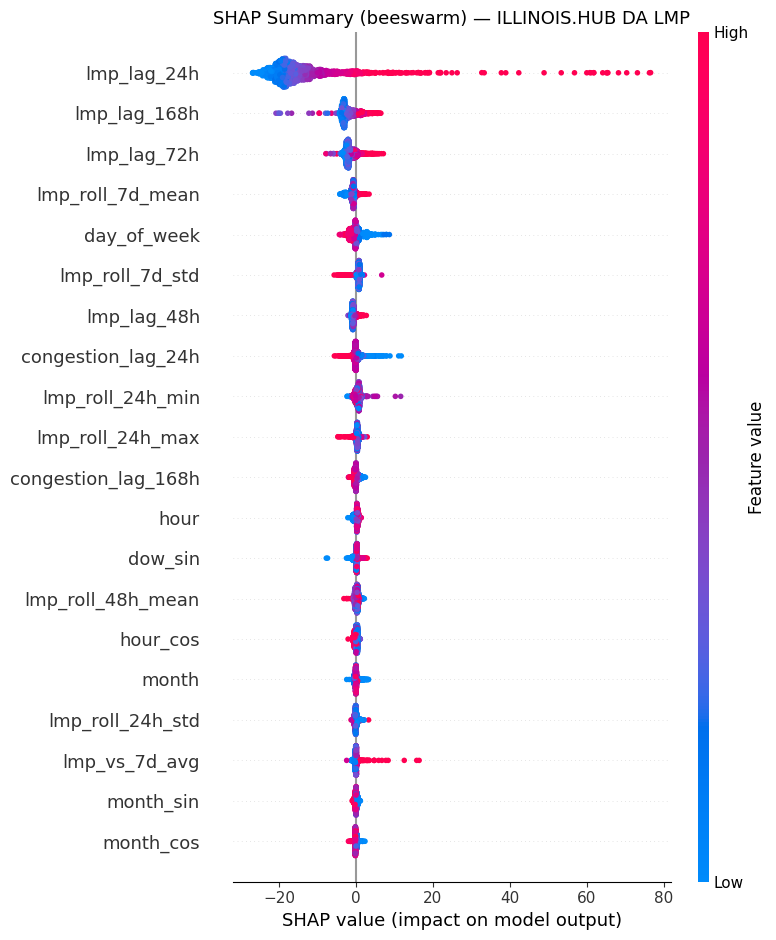

In [5]:
# --- SHAP Summary Plot (beeswarm) ---
# Each dot is one hour: x = SHAP value (push on the prediction), colour = feature value
# (red high / blue low). Shows both importance AND direction in one view.
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=FEATURES,
    max_display=20,
    show=False
)
plt.title('SHAP Summary (beeswarm) — ILLINOIS.HUB DA LMP', fontsize=13)
plt.tight_layout()
plt.savefig('results/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 2 — SHAP Summary Plot (The Most Informative)
Read this carefully — each row is a feature, each dot is one prediction hour:

`lmp_lag_24h` **— Dominant, Massive Range**

- Red dots (high yesterday price) push predictions strongly to the right — by tens of $/MWh on the highest-price hours
- Blue dots (low yesterday price) push predictions left
- The dots stretch far to the right — those are the high-price and polar-vortex hours where yesterday's elevated price correctly signaled "today will also be expensive"
- Translation: Yesterday's price is by far the strongest signal your model uses — even more so now that training spans the high-volatility 2022 regime

`lmp_lag_168h` **— Strong but Narrower**

- Same direction as lag_24h but a much-compressed range
- Weekly seasonality working correctly

`day_of_week` **— Bidirectional**

- Red dots (high day number = weekend) push left (lower price)
- Blue dots (low day number = weekday) push right (higher price)
- This is exactly the weekday/weekend gap you saw in notebook 01 EDA

`congestion_lag_24h` **— Interesting Outliers**

- A few blue dots far left — yesterday's negative congestion correctly predicts lower prices today
- Confirms congestion signal has real predictive value despite being noisy

`month_sin` and `hour` **— Seasonal and Daily Patterns**

- Both show bidirectional effects
- Confirms the model learned the seasonal and daily curves from notebook 01

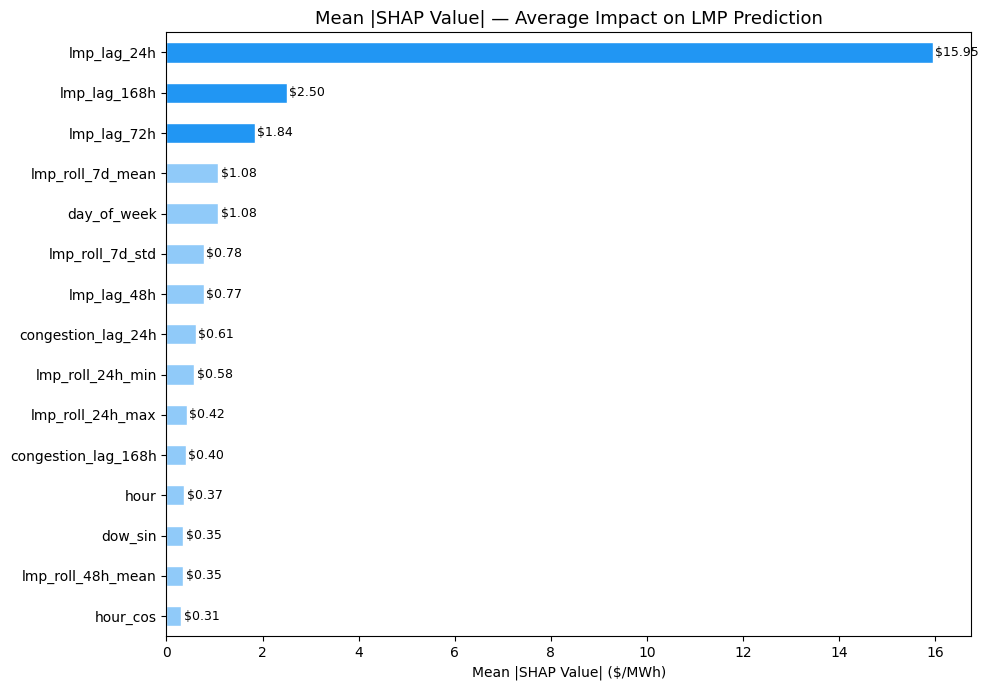

In [6]:
# SHAP Bar Plot (Mean Absolute Impact)

# Mean absolute SHAP value per feature
# Cleaner ranking than the dot plot
shap_mean = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=FEATURES
).sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#2196F3' if i >= len(shap_mean)-3 
          else '#90CAF9' for i in range(len(shap_mean))]
shap_mean.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Mean |SHAP Value| — Average Impact on LMP Prediction',
             fontsize=13)
ax.set_xlabel('Mean |SHAP Value| ($/MWh)')

# Add value labels
for i, (val, name) in enumerate(zip(shap_mean.values, shap_mean.index)):
    ax.text(val + 0.05, i, f'${val:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('results/shap_bar.png', dpi=150)
plt.show()

### Chart 3 - SHAP Bar Plot (Clean Ranking)
```
#1  lmp_lag_24h       $15.95/MWh  ← ~6x more important than #2
#2  lmp_lag_168h      $2.50/MWh
#3  lmp_lag_72h       $1.84/MWh
#4  lmp_roll_7d_mean  $1.08/MWh
#5  day_of_week       $1.08/MWh
```
**The Answer to "What Drives Your Model?"**
**Price momentum dominates — overwhelmingly.** The top 3 features are all lagged LMP values, and `lmp_lag_24h` alone dwarfs everything else. The model is primarily saying "tomorrow's price will look a lot like recent prices, adjusted for day of week and season."

> Note: training on 2022–2023 (which includes the high-price 2022 regime) makes `lmp_lag_24h` an even stronger lever than it was on the 2-year data — when recent prices carry that much range, yesterday's level becomes the single most informative input.

The feature groups ranked by total SHAP impact:
|Group |Features in Top 15| Interpretation|
|------|------------------|---------------|
|Lag LMP| 4 features|Price momentum is #1 driver|
|Temporal|4 features|Hour, day, month patterns|
|Rolling stats| 5 features|Recent market context|
|Congestion lags|2 features|Transmission signal|

<Figure size 1000x500 with 0 Axes>

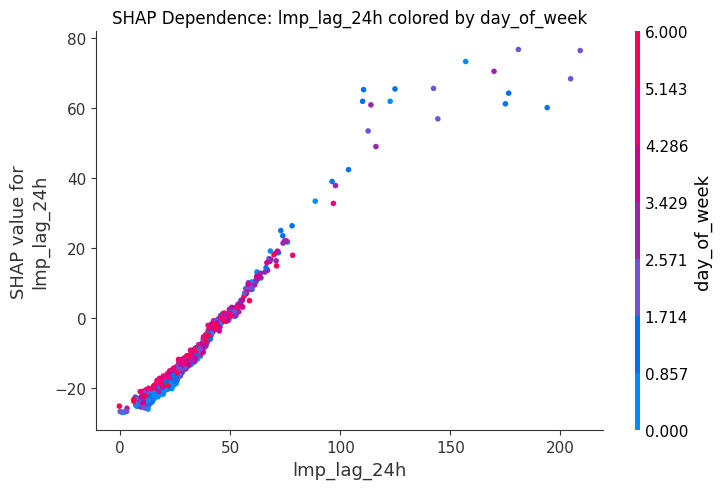

In [7]:
# --- One Final SHAP Plot: Dependence Plot ---
# This shows exactly HOW `lmp_lag_24h` affects predictions

plt.figure(figsize=(10, 5))
shap.dependence_plot(
    'lmp_lag_24h',
    shap_values,
    X_sample,
    interaction_index='day_of_week',
    show=False
)
plt.title("SHAP Dependence: lmp_lag_24h colored by day_of_week", fontsize=12)
plt.tight_layout()
plt.savefig('results/shap_dependence.png', dpi=150)
plt.show()

### Reading the SHAP Dependence Plot
**X-axis**: The actual value of `lmp_lag_24h` (yesterday's price, $/MWh)
**Y-axis**: How much that feature pushed today's prediction up or down
Color: Day of week (blue = Monday=0, red = Sunday=6)

### Three Distinct Regions:
**Region 1 — Low Prices (the dense cluster at left)**
- Tight, near-linear relationship — when yesterday was cheap, today is predicted cheap
- SHAP contribution stays in a modest band around zero
- Colors mixed evenly — day of week doesn't matter much when prices are normal
- Translation: In normal markets, yesterday's price is a reliable, stable signal

**Region 2 — Medium Prices (the steepening middle)**
- SHAP values climb sharply as yesterday's price rises
- This is the "elevated market" regime — prices above normal trigger a non-linear response
- The model has learned that an unusually high yesterday means something unusual is happening
- Translation: The relationship is non-linear — XGBoost correctly learned that high prices beget high prices more than proportionally

**Region 3 — Extreme Prices (the scattered dots at far right)**
- Wide spread of large positive SHAP values
- Those far-right points are the polar-vortex / spike hours, where yesterday's extreme price drives a large upward push
- Look at the coloring here: where weekday vs weekend points separate, it hints at a day-of-week interaction during extreme events

### The Interaction to Look For
The color pattern at the extreme end is where the interesting interaction lives:

If extreme-price weekend hours sit *higher* than extreme-price weekday hours, that reflects a real physical story — during events like a polar vortex, residential heating load dominates and doesn't fall on weekends the way industrial load does, so weekend extreme prices can be stickier. This kind of conditional, non-linear interaction is exactly what a tree model captures automatically and a simple linear model misses.

## Top 3 Features — Deep Dive (for the presentation)

SHAP names the three biggest drivers of the forecast. Below we pull them out programmatically and
plot each one against **today's** LMP, so we can see *why* they're so informative — not just that
they rank highly.

Top 3 features by mean |SHAP|:
  1. lmp_lag_24h       mean|SHAP| = $15.95/MWh   corr with LMP = 0.89
  2. lmp_lag_168h      mean|SHAP| = $ 2.50/MWh   corr with LMP = 0.60
  3. lmp_lag_72h       mean|SHAP| = $ 1.84/MWh   corr with LMP = 0.68


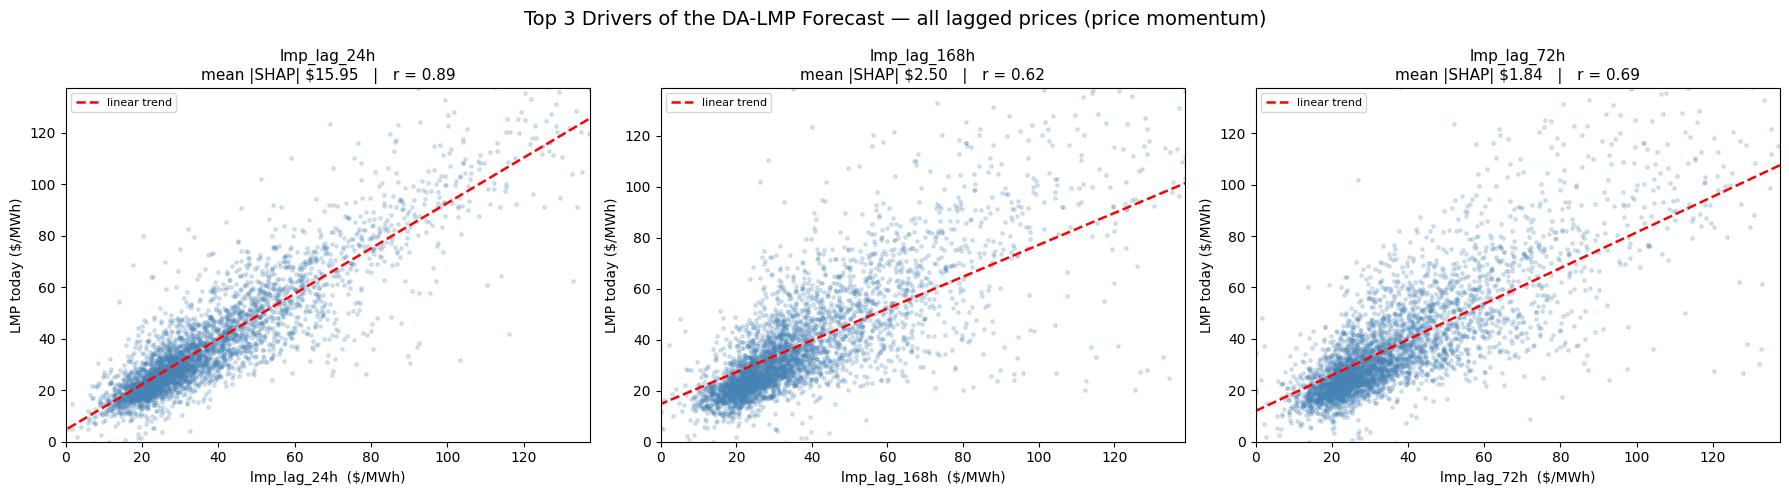

In [8]:
# --- Identify the top 3 features by mean |SHAP|, then analyse each vs today's LMP ---
mean_abs = (pd.Series(np.abs(shap_values).mean(axis=0), index=FEATURES)
              .sort_values(ascending=False))
top3 = mean_abs.head(3)

print("Top 3 features by mean |SHAP|:")
for rank, (feat, val) in enumerate(top3.items(), 1):
    r = np.corrcoef(X[feat], y)[0, 1]
    print(f"  {rank}. {feat:16s}  mean|SHAP| = ${val:5.2f}/MWh   corr with LMP = {r:.2f}")

# Scatter each top feature against today's LMP (sampled for readability) + trend line
rel = X.sample(4000, random_state=1)
yr  = y.loc[rel.index]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, feat in zip(axes, top3.index):
    ax.scatter(rel[feat], yr, s=6, alpha=0.20, color='steelblue')
    r = np.corrcoef(rel[feat], yr)[0, 1]
    b1, b0 = np.polyfit(rel[feat], yr, 1)
    xs = np.linspace(rel[feat].min(), rel[feat].max(), 50)
    ax.plot(xs, b0 + b1 * xs, '--', color='red', linewidth=1.8, label='linear trend')
    hi = max(rel[feat].quantile(0.99), yr.quantile(0.99))
    ax.set_xlim(0, hi); ax.set_ylim(0, hi)
    ax.set_xlabel(f'{feat}  ($/MWh)')
    ax.set_ylabel('LMP today ($/MWh)')
    ax.set_title(f'{feat}\nmean |SHAP| ${top3[feat]:.2f}   |   r = {r:.2f}', fontsize=11)
    ax.legend(fontsize=8)

plt.suptitle('Top 3 Drivers of the DA-LMP Forecast — all lagged prices (price momentum)',
             fontsize=14)
plt.tight_layout()
plt.savefig('results/top3_features.png', dpi=150)
plt.show()

### Analysis — the top 3 are all *lagged prices*

| Rank | Feature | Meaning | mean \|SHAP\| | corr with LMP |
|------|---------|---------|--------------|---------------|
| 1 | `lmp_lag_24h` | price 24 h ago (same hour yesterday) | **$15.95/MWh** | 0.89 |
| 2 | `lmp_lag_168h` | price 168 h ago (same hour last week) | $2.50/MWh | 0.60 |
| 3 | `lmp_lag_72h` | price 72 h ago (same hour 3 days ago) | $1.84/MWh | 0.68 |

**The forecast runs on price momentum.** All three top drivers are the recent price itself at
different lags — the model's core logic is *"tomorrow's price looks a lot like the recent past."*

- **`lmp_lag_24h` dominates (~6× the next feature, r = 0.89).** Yesterday's same-hour price already
  encodes the level, the hour-of-day shape, and the prevailing regime in one number. The scatter is
  tight and nearly 1:1 in the normal range — this single feature does most of the work.
- **`lmp_lag_168h` (last week, same hour)** ranks #2 despite a *lower* correlation (0.60) than #3.
  That's the tell that it carries **complementary** information — weekly seasonality (weekday vs
  weekend alignment) that `lag_24h` misses — so the model leans on it more than raw correlation alone
  would suggest.
- **`lmp_lag_72h` (3 days ago)** adds a short-term trend / smoothing signal (r = 0.68).

**Why this matters for the presentation (the honest caveat):** a forecast built on price momentum is
**robust in normal conditions but blind to exogenous shocks**. Nothing in "recent price" anticipates
a polar vortex or a gas-price jump, which is exactly why the model under-predicts spikes (see
notebook 08). The clear next step is adding *causal* drivers — weather, gas prices, load forecasts.

**Slide image:** `results/top3_features.png`

## SHAP Dependence Plots — Top 3 Features

One SHAP dependence plot per top driver. Each shows, for that feature alone, how its value (x-axis)
maps to its push on the prediction (SHAP value, y-axis) — i.e. the exact shape the model learned for
`lmp_lag_24h`, `lmp_lag_168h`, and `lmp_lag_72h`.

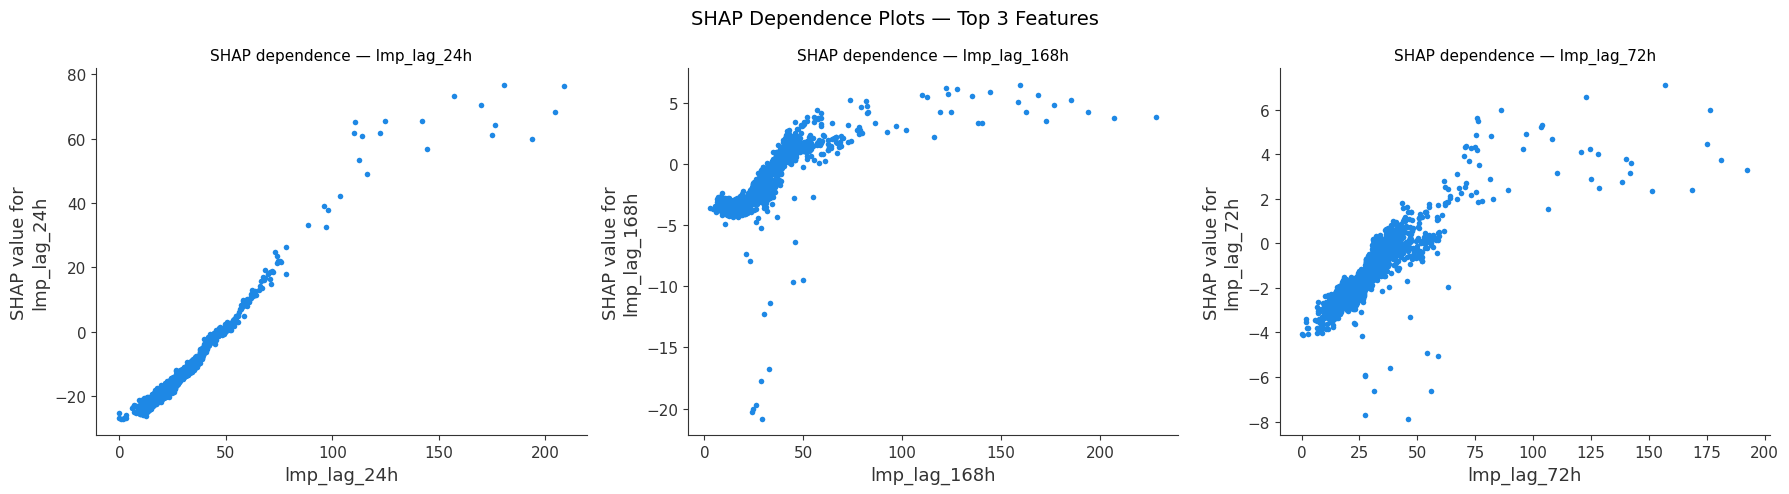

In [9]:
# --- Three SHAP dependence plots, one per top-3 feature ---
top3_feats = (pd.Series(np.abs(shap_values).mean(axis=0), index=FEATURES)
                .sort_values(ascending=False).head(3).index.tolist())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, feat in zip(axes, top3_feats):
    shap.dependence_plot(
        feat,
        shap_values,
        X_sample,
        interaction_index=None,   # no colour/colorbar — keep the 3 panels clean
        ax=ax,
        show=False,
    )
    ax.set_title(f'SHAP dependence — {feat}', fontsize=11)

plt.suptitle('SHAP Dependence Plots — Top 3 Features', fontsize=14)
plt.tight_layout()
plt.savefig('results/top3_dependence.png', dpi=150)
plt.show()